<a href="https://colab.research.google.com/github/aabyyaann/scikit-learn-Cookbook/blob/main/Chapter4_Working_with_Images.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Chapter 4 - Working with Images
**Book:** *scikit-learn Cookbook (O’Reilly)*   
**Name:** Naufal Alif Abyan  
**NIM:** 101032300032

Notebook ini membahas pengolahan data citra (image data) dalam konteks machine learning menggunakan Python dan scikit-learn.  
Fokus utama chapter ini adalah bagaimana gambar direpresentasikan sebagai array numerik, bagaimana mengubah gambar menjadi fitur, dan bagaimana menggunakan fitur tersebut untuk membangun model klasifikasi sederhana.

## Tujuan Chapter
Pada chapter ini, kita akan mempelajari:
1. Representasi gambar sebagai matriks / array numerik.
2. Perbedaan citra grayscale dan citra berwarna.
3. Cara melakukan flatten pada gambar agar bisa digunakan oleh model machine learning.
4. Cara memanfaatkan dataset gambar bawaan dari scikit-learn.
5. Membangun model klasifikasi gambar sederhana menggunakan digits dataset.
6. Mengevaluasi performa model menggunakan accuracy, classification report, dan confusion matrix.
7. Melakukan prediksi pada sampel gambar.

## 1. Konsep Dasar: Image as Data

Dalam machine learning, gambar tidak diproses sebagai "foto" seperti yang dilihat manusia, tetapi sebagai **sekumpulan angka**.

### Representasi gambar
- **Grayscale image** direpresentasikan sebagai matriks 2 dimensi.
  - Setiap elemen matriks mewakili intensitas piksel.
  - Nilai kecil berarti gelap, nilai besar berarti terang.
- **Color image** direpresentasikan sebagai array 3 dimensi.
  - Dimensi 1 = tinggi gambar
  - Dimensi 2 = lebar gambar
  - Dimensi 3 = channel warna (misalnya RGB)

### Mengapa gambar perlu diubah menjadi angka?
Model machine learning bekerja dengan fitur numerik.  
Karena itu, data gambar harus diubah menjadi bentuk numerik agar bisa dipelajari model.

### Hubungan dengan scikit-learn
Sebagian besar model scikit-learn menerima input berbentuk tabel 2 dimensi:
- baris = sampel
- kolom = fitur

Maka gambar sering perlu diubah dari bentuk:
- `(tinggi, lebar)` atau `(tinggi, lebar, channel)`
menjadi:
- `(jumlah_sampel, jumlah_fitur)`

Proses mengubah gambar menjadi satu vektor panjang disebut **flattening**.

In [1]:
# Import library utama
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.datasets import load_digits
from sklearn.model_selection import train_test_split
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

# Supaya output angka lebih rapi
np.set_printoptions(precision=2, suppress=True)

print("Library untuk Chapter 4 berhasil diimport.")

Library untuk Chapter 4 berhasil diimport.


## 2. Simulasi Citra Grayscale sebagai Array

Sebelum memakai dataset gambar sungguhan, kita mulai dari contoh sederhana:
sebuah gambar grayscale kecil berukuran **4 x 4**.

Setiap angka mewakili intensitas piksel:
- 0 = hitam
- nilai besar = semakin terang

In [2]:
# Contoh citra grayscale sederhana 4x4
gray_image = np.array([
    [0, 50, 100, 150],
    [25, 75, 125, 175],
    [50, 100, 150, 200],
    [75, 125, 175, 255]
])

print("Array grayscale:")
print(gray_image)
print("\nShape:", gray_image.shape)

Array grayscale:
[[  0  50 100 150]
 [ 25  75 125 175]
 [ 50 100 150 200]
 [ 75 125 175 255]]

Shape: (4, 4)


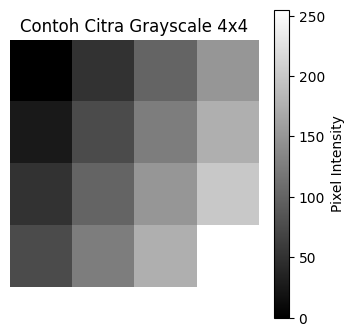

In [3]:
plt.figure(figsize=(4, 4))
plt.imshow(gray_image, cmap="gray")
plt.title("Contoh Citra Grayscale 4x4")
plt.colorbar(label="Pixel Intensity")
plt.axis("off")
plt.show()

## 3. Simulasi Citra Berwarna (RGB)

Gambar berwarna biasanya disimpan dalam bentuk array 3 dimensi:
- tinggi
- lebar
- 3 channel warna: **Red, Green, Blue**

Berikut contoh citra kecil berukuran **2 x 2 x 3**.

In [4]:
# Contoh citra RGB kecil 2x2
rgb_image = np.array([
    [[255, 0, 0], [0, 255, 0]],
    [[0, 0, 255], [255, 255, 0]]
], dtype=np.uint8)

print("Array RGB:")
print(rgb_image)
print("\nShape:", rgb_image.shape)

Array RGB:
[[[255   0   0]
  [  0 255   0]]

 [[  0   0 255]
  [255 255   0]]]

Shape: (2, 2, 3)


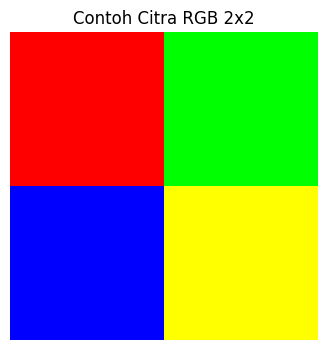

In [5]:
plt.figure(figsize=(4, 4))
plt.imshow(rgb_image)
plt.title("Contoh Citra RGB 2x2")
plt.axis("off")
plt.show()

## 4. Flattening: Mengubah Gambar Menjadi Vektor Fitur

Model machine learning klasik seperti:
- Logistic Regression
- SVM
- KNN
- Decision Tree

umumnya menerima input 2 dimensi:
- baris = sampel
- kolom = fitur

Karena itu, gambar sering perlu di-*flatten*.
Contoh:
- gambar 4x4 memiliki 16 piksel
- setelah di-flatten menjadi vektor panjang 16 elemen

In [6]:
gray_flat = gray_image.flatten()

print("Array hasil flatten:")
print(gray_flat)
print("\nPanjang vektor:", len(gray_flat))

Array hasil flatten:
[  0  50 100 150  25  75 125 175  50 100 150 200  75 125 175 255]

Panjang vektor: 16


## 5. Dataset Gambar dari scikit-learn: Digits Dataset

Untuk praktik klasifikasi gambar, kita menggunakan **digits dataset** dari scikit-learn.

### Tentang dataset digits
Dataset ini berisi gambar angka tulisan tangan:
- label: 0 sampai 9
- total sampel: 1797
- setiap gambar berukuran 8 x 8 piksel

Artinya:
- satu gambar = 64 fitur jika di-flatten
- target = digit yang direpresentasikan gambar tersebut

In [7]:
digits = load_digits()

print("Keys pada dataset:", digits.keys())
print("Jumlah data:", digits.data.shape[0])
print("Jumlah fitur per sampel:", digits.data.shape[1])
print("Shape image asli:", digits.images.shape)
print("Label unik:", np.unique(digits.target))

Keys pada dataset: dict_keys(['data', 'target', 'frame', 'feature_names', 'target_names', 'images', 'DESCR'])
Jumlah data: 1797
Jumlah fitur per sampel: 64
Shape image asli: (1797, 8, 8)
Label unik: [0 1 2 3 4 5 6 7 8 9]


In [8]:
# Menyimpan data ke variabel yang lebih mudah dipakai
X = digits.data       # versi flatten: (n_samples, 64)
y = digits.target     # label digit
images = digits.images  # versi gambar asli: (n_samples, 8, 8)

print("Shape X:", X.shape)
print("Shape y:", y.shape)
print("Shape images:", images.shape)

Shape X: (1797, 64)
Shape y: (1797,)
Shape images: (1797, 8, 8)


## 6. Melihat Beberapa Sampel Gambar

Sebelum membangun model, kita lihat beberapa contoh gambar digit dari dataset.
Ini penting untuk memahami seperti apa data yang dipelajari model.

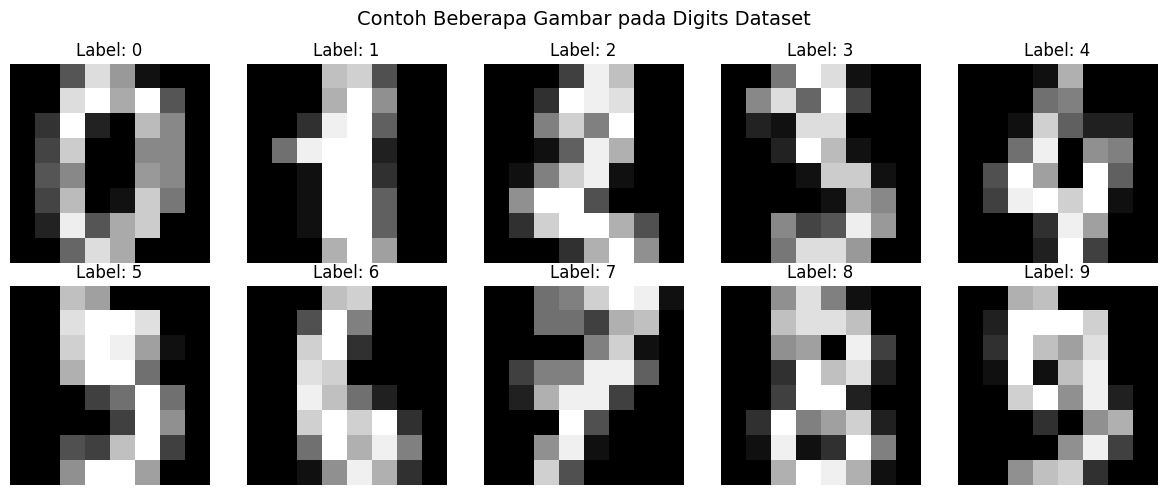

In [9]:
fig, axes = plt.subplots(2, 5, figsize=(12, 5))

for i, ax in enumerate(axes.ravel()):
    ax.imshow(images[i], cmap="gray")
    ax.set_title(f"Label: {y[i]}")
    ax.axis("off")

plt.suptitle("Contoh Beberapa Gambar pada Digits Dataset", fontsize=14)
plt.tight_layout()
plt.show()

## 7. Memahami Struktur Data Digits

Setiap gambar pada dataset digits:
- ukuran asli: **8 x 8**
- jika diubah menjadi vektor, panjangnya menjadi **64**

Artinya, satu gambar dapat diperlakukan sebagai satu baris data dengan 64 fitur numerik.

In [10]:
sample_index = 0

print("Label sampel:", y[sample_index])
print("\nBentuk gambar asli (8x8):")
print(images[sample_index])

print("\nVersi flatten (64 fitur):")
print(X[sample_index])

Label sampel: 0

Bentuk gambar asli (8x8):
[[ 0.  0.  5. 13.  9.  1.  0.  0.]
 [ 0.  0. 13. 15. 10. 15.  5.  0.]
 [ 0.  3. 15.  2.  0. 11.  8.  0.]
 [ 0.  4. 12.  0.  0.  8.  8.  0.]
 [ 0.  5.  8.  0.  0.  9.  8.  0.]
 [ 0.  4. 11.  0.  1. 12.  7.  0.]
 [ 0.  2. 14.  5. 10. 12.  0.  0.]
 [ 0.  0.  6. 13. 10.  0.  0.  0.]]

Versi flatten (64 fitur):
[ 0.  0.  5. 13.  9.  1.  0.  0.  0.  0. 13. 15. 10. 15.  5.  0.  0.  3.
 15.  2.  0. 11.  8.  0.  0.  4. 12.  0.  0.  8.  8.  0.  0.  5.  8.  0.
  0.  9.  8.  0.  0.  4. 11.  0.  1. 12.  7.  0.  0.  2. 14.  5. 10. 12.
  0.  0.  0.  0.  6. 13. 10.  0.  0.  0.]


## 8. Membuat DataFrame agar Mudah Dibaca

Walaupun model scikit-learn bisa langsung menggunakan array NumPy, kadang DataFrame membantu untuk:
- melihat struktur data
- melakukan inspeksi fitur
- menampilkan beberapa baris awal

In [11]:
feature_names = [f"pixel_{i}" for i in range(X.shape[1])]
df_digits = pd.DataFrame(X, columns=feature_names)
df_digits["target"] = y

print(df_digits.head())
print("\nShape DataFrame:", df_digits.shape)

   pixel_0  pixel_1  pixel_2  pixel_3  pixel_4  pixel_5  pixel_6  pixel_7  \
0      0.0      0.0      5.0     13.0      9.0      1.0      0.0      0.0   
1      0.0      0.0      0.0     12.0     13.0      5.0      0.0      0.0   
2      0.0      0.0      0.0      4.0     15.0     12.0      0.0      0.0   
3      0.0      0.0      7.0     15.0     13.0      1.0      0.0      0.0   
4      0.0      0.0      0.0      1.0     11.0      0.0      0.0      0.0   

   pixel_8  pixel_9  ...  pixel_55  pixel_56  pixel_57  pixel_58  pixel_59  \
0      0.0      0.0  ...       0.0       0.0       0.0       6.0      13.0   
1      0.0      0.0  ...       0.0       0.0       0.0       0.0      11.0   
2      0.0      0.0  ...       0.0       0.0       0.0       0.0       3.0   
3      0.0      8.0  ...       0.0       0.0       0.0       7.0      13.0   
4      0.0      0.0  ...       0.0       0.0       0.0       0.0       2.0   

   pixel_60  pixel_61  pixel_62  pixel_63  target  
0      10.0     

In [12]:
df_digits.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1797 entries, 0 to 1796
Data columns (total 65 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   pixel_0   1797 non-null   float64
 1   pixel_1   1797 non-null   float64
 2   pixel_2   1797 non-null   float64
 3   pixel_3   1797 non-null   float64
 4   pixel_4   1797 non-null   float64
 5   pixel_5   1797 non-null   float64
 6   pixel_6   1797 non-null   float64
 7   pixel_7   1797 non-null   float64
 8   pixel_8   1797 non-null   float64
 9   pixel_9   1797 non-null   float64
 10  pixel_10  1797 non-null   float64
 11  pixel_11  1797 non-null   float64
 12  pixel_12  1797 non-null   float64
 13  pixel_13  1797 non-null   float64
 14  pixel_14  1797 non-null   float64
 15  pixel_15  1797 non-null   float64
 16  pixel_16  1797 non-null   float64
 17  pixel_17  1797 non-null   float64
 18  pixel_18  1797 non-null   float64
 19  pixel_19  1797 non-null   float64
 20  pixel_20  1797 non-null   floa

## 9. Mengecek Distribusi Label

Karena ini adalah tugas klasifikasi, penting untuk melihat apakah jumlah sampel tiap kelas relatif seimbang atau tidak.

In [13]:
label_counts = pd.Series(y).value_counts().sort_index()
print(label_counts)

0    178
1    182
2    177
3    183
4    181
5    182
6    181
7    179
8    174
9    180
Name: count, dtype: int64


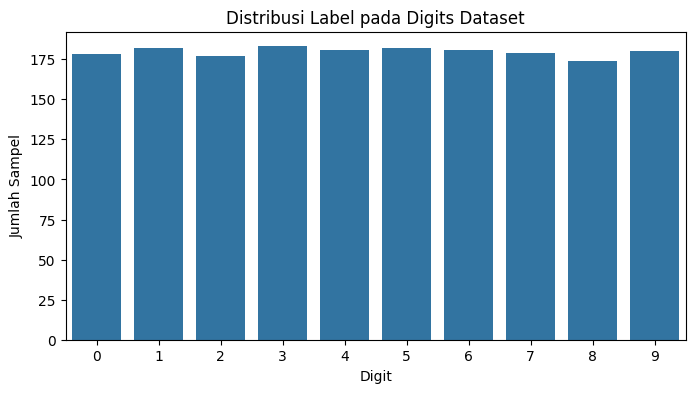

In [14]:
plt.figure(figsize=(8, 4))
sns.countplot(x=y)
plt.title("Distribusi Label pada Digits Dataset")
plt.xlabel("Digit")
plt.ylabel("Jumlah Sampel")
plt.show()

## 10. Train-Test Split

Agar evaluasi model adil, data dibagi menjadi:
- **training set** → digunakan untuk melatih model
- **test set** → digunakan untuk mengevaluasi kemampuan generalisasi model

Kita gunakan `stratify=y` agar proporsi masing-masing digit tetap seimbang di train dan test.

In [15]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print("Shape X_train:", X_train.shape)
print("Shape X_test :", X_test.shape)
print("Shape y_train:", y_train.shape)
print("Shape y_test :", y_test.shape)

Shape X_train: (1437, 64)
Shape X_test : (360, 64)
Shape y_train: (1437,)
Shape y_test : (360,)


## 11. Model Klasifikasi Gambar Sederhana: K-Nearest Neighbors

Untuk chapter ini kita gunakan **K-Nearest Neighbors (KNN)** sebagai model awal karena:
1. mudah dipahami,
2. cocok untuk contoh klasifikasi sederhana,
3. dapat langsung bekerja pada fitur numerik hasil flatten.

Ide KNN:
- cari tetangga terdekat dari sampel baru
- lihat label tetangga-tetangga tersebut
- pilih label mayoritas sebagai prediksi

In [16]:
knn = KNeighborsClassifier(n_neighbors=3)
knn.fit(X_train, y_train)

print("Model KNN berhasil dilatih.")

Model KNN berhasil dilatih.


## 12. Evaluasi Model pada Training dan Test Set

Kita akan melihat:
- akurasi training
- akurasi test

Jika akurasi training jauh lebih tinggi daripada test, itu bisa menjadi indikasi overfitting.

In [17]:
train_score = knn.score(X_train, y_train)
test_score = knn.score(X_test, y_test)

print("Training Accuracy:", round(train_score, 4))
print("Test Accuracy    :", round(test_score, 4))

Training Accuracy: 0.9937
Test Accuracy    : 0.9861


## 13. Prediksi pada Test Set

Sekarang kita gunakan model untuk memprediksi label digit pada data test.

In [18]:
y_pred = knn.predict(X_test)

print("5 prediksi pertama:", y_pred[:5])
print("5 label asli      :", y_test[:5])

5 prediksi pertama: [5 2 8 1 7]
5 label asli      : [5 2 8 1 7]


## 14. Accuracy Score

Accuracy adalah proporsi prediksi yang benar terhadap seluruh sampel.
Untuk klasifikasi multi-class seperti digits, accuracy adalah metrik awal yang cukup mudah dipahami.

In [19]:
acc = accuracy_score(y_test, y_pred)
print("Accuracy:", round(acc, 4))

Accuracy: 0.9861


## 15. Classification Report

Classification report menampilkan:
- precision
- recall
- f1-score
- support

untuk masing-masing kelas digit 0–9.

In [20]:
report = classification_report(y_test, y_pred)
print(report)

              precision    recall  f1-score   support

           0       1.00      1.00      1.00        36
           1       0.92      1.00      0.96        36
           2       1.00      1.00      1.00        35
           3       1.00      1.00      1.00        37
           4       0.97      1.00      0.99        36
           5       1.00      1.00      1.00        37
           6       1.00      1.00      1.00        36
           7       1.00      1.00      1.00        36
           8       0.97      0.91      0.94        35
           9       1.00      0.94      0.97        36

    accuracy                           0.99       360
   macro avg       0.99      0.99      0.99       360
weighted avg       0.99      0.99      0.99       360



## 16. Confusion Matrix

Confusion matrix membantu melihat:
- digit mana yang paling sering benar
- digit mana yang sering tertukar dengan digit lain

In [21]:
cm = confusion_matrix(y_test, y_pred)
print(cm)

[[36  0  0  0  0  0  0  0  0  0]
 [ 0 36  0  0  0  0  0  0  0  0]
 [ 0  0 35  0  0  0  0  0  0  0]
 [ 0  0  0 37  0  0  0  0  0  0]
 [ 0  0  0  0 36  0  0  0  0  0]
 [ 0  0  0  0  0 37  0  0  0  0]
 [ 0  0  0  0  0  0 36  0  0  0]
 [ 0  0  0  0  0  0  0 36  0  0]
 [ 0  3  0  0  0  0  0  0 32  0]
 [ 0  0  0  0  1  0  0  0  1 34]]


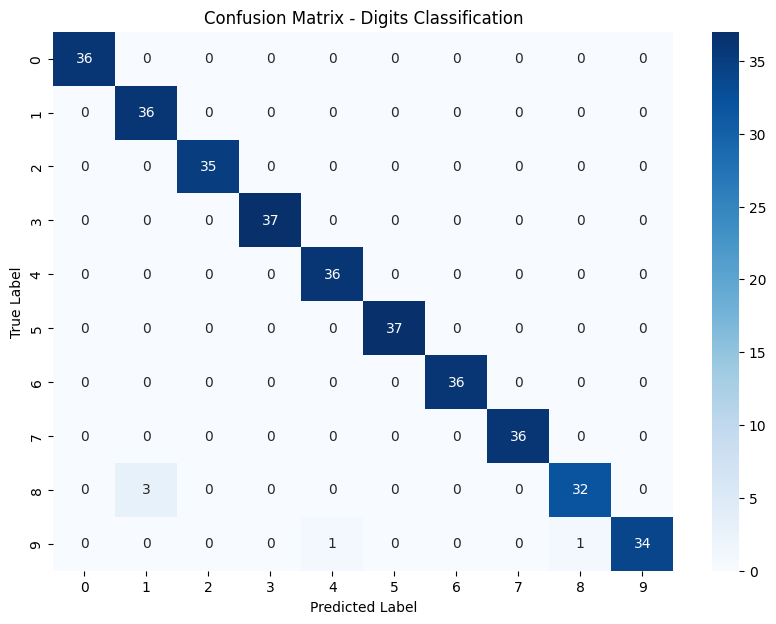

In [22]:
plt.figure(figsize=(10, 7))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues")
plt.title("Confusion Matrix - Digits Classification")
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.show()

## 17. Visualisasi Hasil Prediksi pada Beberapa Sampel

Kita tampilkan beberapa gambar dari test set beserta:
- label sebenarnya
- label prediksi model

Tujuannya agar hasil model lebih mudah dipahami secara visual.

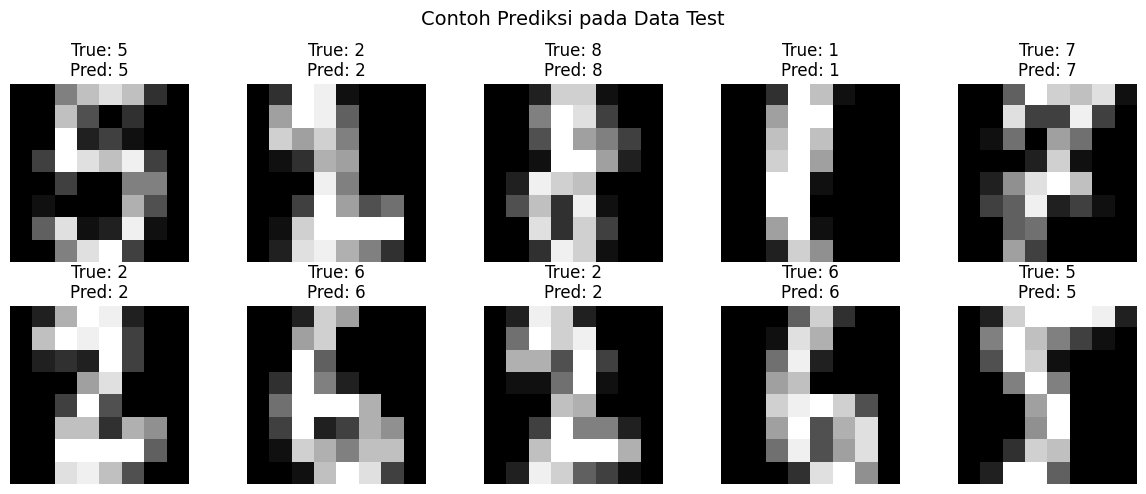

In [23]:
fig, axes = plt.subplots(2, 5, figsize=(12, 5))

for i, ax in enumerate(axes.ravel()):
    ax.imshow(X_test[i].reshape(8, 8), cmap="gray")
    ax.set_title(f"True: {y_test[i]}\nPred: {y_pred[i]}")
    ax.axis("off")

plt.suptitle("Contoh Prediksi pada Data Test", fontsize=14)
plt.tight_layout()
plt.show()

## 18. Mencoba Beberapa Nilai K

Seperti pada chapter supervised learning sebelumnya, nilai `n_neighbors` memengaruhi kompleksitas model KNN.

Kita akan menguji beberapa nilai K untuk melihat pengaruhnya terhadap akurasi.

In [24]:
results_k = []

for k in range(1, 11):
    model = KNeighborsClassifier(n_neighbors=k)
    model.fit(X_train, y_train)

    train_acc = model.score(X_train, y_train)
    test_acc = model.score(X_test, y_test)

    results_k.append([k, train_acc, test_acc])

df_k = pd.DataFrame(results_k, columns=["k", "train_accuracy", "test_accuracy"])
df_k

,k,train_accuracy,test_accuracy
0,1,1.000000,0.986111
1,2,0.991649,0.986111
2,3,0.993737,0.986111
3,4,0.993737,0.983333
4,5,0.991649,0.983333
5,6,0.989562,0.980556
6,7,0.990257,0.983333
7,8,0.989562,0.977778
8,9,0.987474,0.980556
9,10,0.986082,0.977778


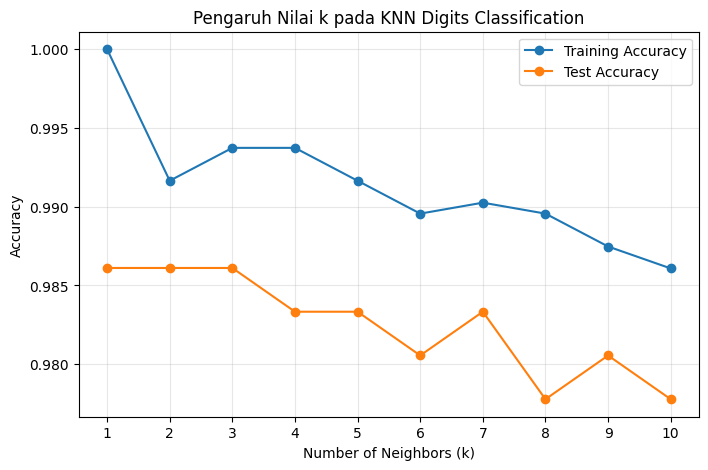

In [25]:
plt.figure(figsize=(8, 5))
plt.plot(df_k["k"], df_k["train_accuracy"], marker="o", label="Training Accuracy")
plt.plot(df_k["k"], df_k["test_accuracy"], marker="o", label="Test Accuracy")
plt.xlabel("Number of Neighbors (k)")
plt.ylabel("Accuracy")
plt.title("Pengaruh Nilai k pada KNN Digits Classification")
plt.xticks(df_k["k"])
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

## 19. Prediksi Satu Sampel Baru dari Data Test

Sebagai simulasi penggunaan model, kita ambil satu sampel dari data test lalu lihat:
- gambar digitnya
- label asli
- hasil prediksi model

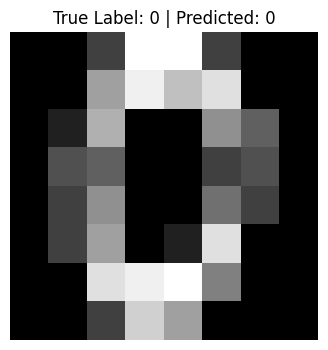

In [26]:
sample_idx = 10
sample_image = X_test[sample_idx].reshape(8, 8)
sample_true = y_test[sample_idx]
sample_pred = knn.predict([X_test[sample_idx]])[0]

plt.figure(figsize=(4, 4))
plt.imshow(sample_image, cmap="gray")
plt.title(f"True Label: {sample_true} | Predicted: {sample_pred}")
plt.axis("off")
plt.show()

## 20. Ringkasan Hasil Eksperimen

Pada chapter ini kita sudah melakukan alur dasar pengolahan citra untuk machine learning:
1. memahami bahwa gambar adalah data numerik,
2. melihat representasi grayscale dan RGB,
3. melakukan flatten agar gambar menjadi fitur,
4. menggunakan digits dataset,
5. membangun model klasifikasi dengan KNN,
6. mengevaluasi model dengan accuracy, classification report, dan confusion matrix.

Walaupun digits dataset sangat kecil dibandingkan citra modern, konsep dasarnya tetap sama:
- gambar harus direpresentasikan sebagai angka,
- fitur harus disusun agar sesuai dengan input model,
- performa model harus dievaluasi secara objektif.

## 21. Kesimpulan Chapter 4

Beberapa poin penting dari chapter ini:

- Gambar dalam machine learning direpresentasikan sebagai array numerik.
- Grayscale image biasanya berbentuk matriks 2D, sedangkan color image berbentuk array 3D.
- Agar dapat digunakan oleh banyak model scikit-learn, gambar sering diubah menjadi vektor fitur melalui proses flattening.
- Dataset digits dari scikit-learn adalah contoh sederhana yang sangat baik untuk mempelajari klasifikasi gambar.
- KNN dapat digunakan untuk mengklasifikasikan gambar digit dengan performa yang cukup baik.
- Evaluasi menggunakan accuracy, classification report, dan confusion matrix membantu memahami kekuatan dan kelemahan model.

Chapter ini menjadi penghubung penting antara data citra dan machine learning klasik sebelum masuk ke topik yang lebih kompleks.